# Notebook 02 — Text Preprocessing

**Project:** FUSE — Feature Unification for Semantic Exploration

**Objective:** Clean and prepare all text fields for NLP feature engineering.

**Pipeline:**
1. Filter dataset (English movies with non-empty overviews)
2. Fill missing text fields
3. Text cleaning (lowercase, remove noise)
4. Tokenization, stopword removal, lemmatization (NLTK)
5. Create combined text field for TF-IDF / LDA
6. Save preprocessed dataset

---

## 2.1 — Setup & Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── NLTK Setup ──
try:
    import nltk
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    from nltk.corpus import stopwords
    from nltk.tokenize import word_tokenize
    from nltk.stem import WordNetLemmatizer
    NLTK_AVAILABLE = True
    print('NLTK loaded successfully.')
except ImportError:
    NLTK_AVAILABLE = False
    print('NLTK not available — using regex-based fallback.')

# ── Color Theme ──
GOLD = '#eab308'
BLACK = '#050505'
WHITE = '#ffffff'
GRAY = '#888888'

plt.rcParams.update({
    'figure.facecolor': WHITE, 'axes.facecolor': WHITE,
    'axes.edgecolor': BLACK, 'axes.labelcolor': BLACK,
    'text.color': BLACK, 'xtick.color': BLACK, 'ytick.color': BLACK,
    'font.size': 11, 'axes.titlesize': 14, 'figure.dpi': 100
})

NLTK loaded successfully.


In [2]:
df = pd.read_csv('../Artifacts/preprocessing/cleaned_movies.csv')
print(f'Original dataset: {df.shape[0]} movies, {df.shape[1]} columns')

Original dataset: 27777 movies, 20 columns


## 2.2 — Filtering

We restrict to English-language movies with non-empty overviews. This ensures our NLP pipeline operates on text that English-trained models can process reliably.

In [3]:
print(f'Before filtering: {len(df)} movies')
df = df[df['original_language'] == 'en'].copy()
print(f'After English filter: {len(df)}')
df = df[df['overview'].notna() & (df['overview'].str.strip() != '')].copy()
df = df.reset_index(drop=True)
print(f'After removing empty overviews: {len(df)}')

Before filtering: 27777 movies
After English filter: 18222
After removing empty overviews: 18220


## 2.3 — Handle Missing Text Fields

In [4]:
for col in ['tagline', 'keywords']:
    n_missing = df[col].isna().sum()
    df[col] = df[col].fillna('')
    print(f'{col}: filled {n_missing} missing ({n_missing/len(df)*100:.1f}%) with empty string')

tagline: filled 3629 missing (19.9%) with empty string
keywords: filled 1528 missing (8.4%) with empty string


## 2.4 — Text Cleaning

Cleaning steps: lowercase, remove URLs/HTML, remove non-alphabetic characters, collapse whitespace.

In [5]:
def clean_text(text):
    """Basic text cleaning: lowercase, remove noise, normalize whitespace."""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

sample = df.iloc[0]['overview']
print(f'Raw:     {sample[:120]}')
print(f'Cleaned: {clean_text(sample)[:120]}')

Raw:     Cobb, a skilled thief who commits corporate espionage by infiltrating the subconscious of his targets is offered a chanc
Cleaned: cobb a skilled thief who commits corporate espionage by infiltrating the subconscious of his targets is offered a chance


In [6]:
df['overview_clean'] = df['overview'].apply(clean_text)
df['tagline_clean'] = df['tagline'].apply(clean_text)
df['keywords_clean'] = df['keywords'].apply(lambda x: clean_text(str(x).replace(',', ' ')))
print('Cleaning applied to overview, tagline, keywords.')

Cleaning applied to overview, tagline, keywords.


## 2.5 — Tokenization, Stopword Removal & Lemmatization

If NLTK is available, we use `word_tokenize` + `WordNetLemmatizer`. Otherwise, a regex-based fallback handles tokenization and stopword removal.

In [7]:
if NLTK_AVAILABLE:
    _stop_words = set(stopwords.words('english'))
    _lemmatizer = WordNetLemmatizer()
    def preprocess_text(text):
        if not text:
            return ''
        tokens = word_tokenize(text)
        tokens = [_lemmatizer.lemmatize(t) for t in tokens if t not in _stop_words and len(t) > 2]
        return ' '.join(tokens)
else:
    _stop_words = {'the','a','an','and','of','to','in','is','it','that','was','for',
                   'on','are','with','as','at','by','from','or','be','this','which',
                   'have','not','but','had','has','his','her','they','he','she','their',
                   'its','been','do','did','will','would','can','could','should','may',
                   'might','than','them','what','who','where','when','how','all','each',
                   'every','both','few','more','most','other','some','such','no','nor',
                   'only','own','same','so','about','up','out','into','over','after',
                   'again','then','once','here','there','just','also','very','often',
                   'still','already','through','during','before','between','under',
                   'above','being','does','doing','done','having','were','am'}
    def preprocess_text(text):
        if not text:
            return ''
        tokens = text.split()
        tokens = [t for t in tokens if t not in _stop_words and len(t) > 2]
        return ' '.join(tokens)

sample_clean = df.iloc[0]['overview_clean']
print(f'Input:  {sample_clean[:100]}')
print(f'Output: {preprocess_text(sample_clean)[:100]}')

Input:  cobb a skilled thief who commits corporate espionage by infiltrating the subconscious of his targets
Output: cobb skilled thief commits corporate espionage infiltrating subconscious target offered chance regai


In [8]:
%%time
df['overview_processed'] = df['overview_clean'].apply(preprocess_text)
df['tagline_processed'] = df['tagline_clean'].apply(preprocess_text)
df['keywords_processed'] = df['keywords_clean'].apply(preprocess_text)
print('Preprocessing complete for all text fields.')

Preprocessing complete for all text fields.
CPU times: total: 5.92 s
Wall time: 5.92 s


## 2.6 — Combined Text Field

We merge the three processed text fields into `combined_text`. This unified field will serve as input for TF-IDF and LDA. The raw `overview` is kept separately for sentence embeddings.

In [9]:
df['combined_text'] = (
    df['overview_processed'] + ' ' +
    df['tagline_processed'] + ' ' +
    df['keywords_processed']
).str.strip()

empty_count = (df['combined_text'] == '').sum()
print(f'Movies with empty combined_text: {empty_count}')
if empty_count > 0:
    df = df[df['combined_text'] != ''].reset_index(drop=True)
    print(f'Removed empty rows. Remaining: {len(df)}')

print(f'\nSample (Inception):')
print(df['combined_text'].iloc[0][:150])

Movies with empty combined_text: 0

Sample (Inception):
cobb skilled thief commits corporate espionage infiltrating subconscious target offered chance regain old life payment task considered impossible ince


## 2.7 — Before vs. After Comparison

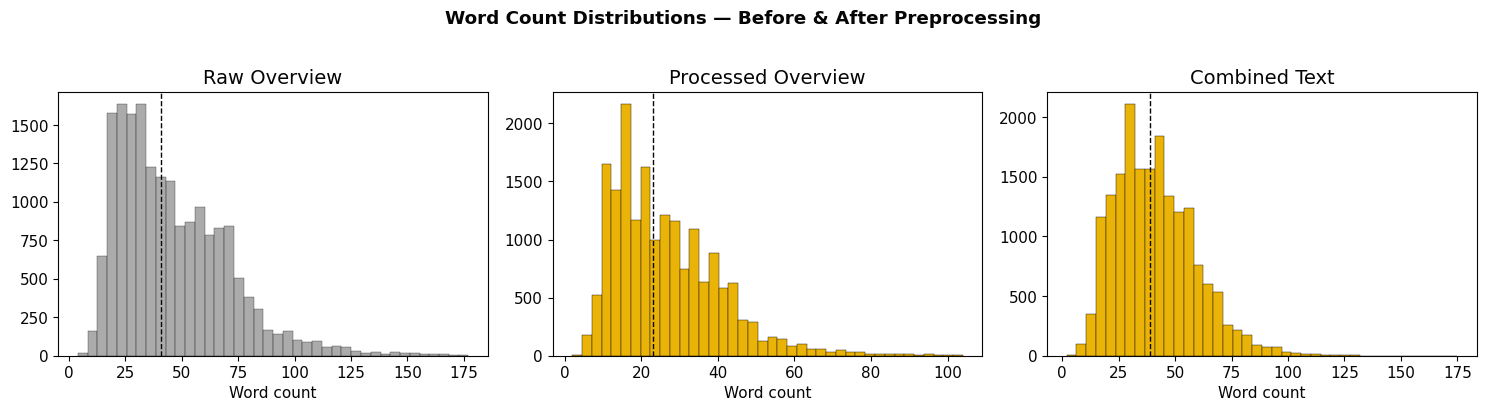

Raw overview  — mean: 46.2, median: 41
Processed     — mean: 26.4, median: 23
Combined text — mean: 41.1, median: 39
Reduction (overview): 42.9%


In [10]:
raw_wc = df['overview'].str.split().apply(len)
proc_wc = df['overview_processed'].str.split().apply(len)
combined_wc = df['combined_text'].str.split().apply(len)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(raw_wc, bins=40, color=GRAY, edgecolor=BLACK, linewidth=0.3, alpha=0.7)
axes[0].set_title('Raw Overview')
axes[0].axvline(raw_wc.median(), color=BLACK, linestyle='--', linewidth=1)
axes[0].set_xlabel('Word count')

axes[1].hist(proc_wc, bins=40, color=GOLD, edgecolor=BLACK, linewidth=0.3)
axes[1].set_title('Processed Overview')
axes[1].axvline(proc_wc.median(), color=BLACK, linestyle='--', linewidth=1)
axes[1].set_xlabel('Word count')

axes[2].hist(combined_wc, bins=40, color=GOLD, edgecolor=BLACK, linewidth=0.3)
axes[2].set_title('Combined Text')
axes[2].axvline(combined_wc.median(), color=BLACK, linestyle='--', linewidth=1)
axes[2].set_xlabel('Word count')

fig.suptitle('Word Count Distributions — Before & After Preprocessing', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Raw overview  — mean: {raw_wc.mean():.1f}, median: {raw_wc.median():.0f}')
print(f'Processed     — mean: {proc_wc.mean():.1f}, median: {proc_wc.median():.0f}')
print(f'Combined text — mean: {combined_wc.mean():.1f}, median: {combined_wc.median():.0f}')
print(f'Reduction (overview): {(1 - proc_wc.mean()/raw_wc.mean())*100:.1f}%')

## 2.8 — Post-Processing Vocabulary

Total tokens: 748,143
Vocabulary size: 33,962


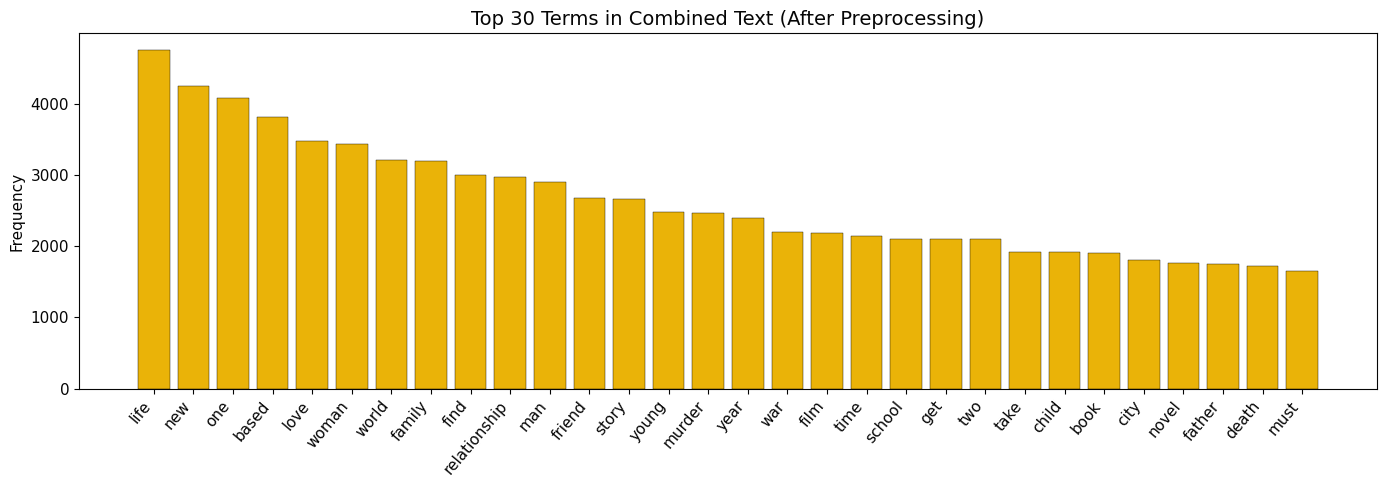

In [11]:
all_tokens = []
for text in df['combined_text']:
    all_tokens.extend(text.split())

vocab = Counter(all_tokens)
print(f'Total tokens: {len(all_tokens):,}')
print(f'Vocabulary size: {len(vocab):,}')

top30 = vocab.most_common(30)
words, counts = zip(*top30)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(words, counts, color=GOLD, edgecolor=BLACK, linewidth=0.3)
ax.set_title('Top 30 Terms in Combined Text (After Preprocessing)')
ax.set_ylabel('Frequency')
plt.xticks(rotation=50, ha='right')
plt.tight_layout()
plt.show()

## 2.9 — Genre List Preparation

In [12]:
df['genre_list'] = df['genres'].apply(lambda x: [g.strip() for g in str(x).split(',')])
all_genres = sorted(set(g for gl in df['genre_list'] for g in gl))
print(f'Unique genres ({len(all_genres)}): {all_genres}')
print(f'Average genres per movie: {df["genre_list"].apply(len).mean():.1f}')

Unique genres (19): ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']
Average genres per movie: 2.5


## 2.10 — Save Preprocessed Data

In [13]:
cols_to_save = [
    'id', 'title', 'vote_average', 'vote_count', 'runtime', 'popularity',
    'original_language', 'release_year',
    'overview', 'tagline', 'keywords', 'genres',
    'overview_clean', 'tagline_clean', 'keywords_clean',
    'overview_processed', 'tagline_processed', 'keywords_processed',
    'combined_text', 'genre_list'
]

df[cols_to_save].to_csv('../Artifacts/preprocessing/movies_preprocessed.csv', index=False)
print(f'Saved: {len(df)} movies, {len(cols_to_save)} columns')
print(f'Output: ../Artifacts/preprocessing/movies_preprocessed.csv')

Saved: 18220 movies, 20 columns
Output: ../Artifacts/preprocessing/movies_preprocessed.csv


## Summary

**Preprocessing pipeline:**
- Filtered to English movies with overviews → ~18,200 movies
- Cleaned text: lowercased, removed URLs/HTML/special chars
- Tokenized, removed stopwords, lemmatized
- Created `combined_text` = overview + tagline + keywords (processed)
- Preserved raw `overview` for SBERT embeddings in Notebook 03

**Output:** `movies_preprocessed.csv`

**Next:** Notebook 03 — Feature Engineering